# 💰 Notebook 4: Budget Allocation Prediction

**Task Type**: Regression (Complex Multi-variable)

**Goal**: Predict the optimal budget allocation for scout units based on activities, members, and operational needs.


**Models**: Random Forest, Gradient Boosting, SVR, KNN, Linear Regression

**Output**: Budget predictions with comprehensive evaluation metrics

## 2. Compréhension des Données (Data Understanding)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score, silhouette_score
import joblib
import warnings
warnings.filterwarnings('ignore')

### Remarque sur les données
Les datasets réels étant très petits (quelques lignes), nous allons utiliser les statistiques réelles des fichiers pour générer un jeu de données synthétique réaliste afin de pouvoir entraîner des modèles de Machine Learning performants.

In [37]:
# Load real data and extract realistic statistics with enhanced features
import os

budget_path = 'Data/Budgets_et_Finances.xlsx'
activities_path = 'Data/Activités par Unité et Saison.xlsx'
members_path = 'Data/Membres par Unité et Saison.xlsx'
activity_costs_path = 'Data/Budgets par Type d\'Activité.xlsx'
camps_path = 'Data/Camps_Detailles.xlsx'

print("=" * 80)
print("LOADING REAL DATA FROM MULTIPLE SOURCES FOR ENHANCED FEATURES")
print("=" * 80)

try:
    # Load all real data files
    df_budget_real = pd.read_excel(budget_path)
    df_activities_real = pd.read_excel(activities_path)
    df_members_real = pd.read_excel(members_path)
    
    # Try to load additional data for feature engineering
    try:
        df_activity_costs = pd.read_excel(activity_costs_path)
        print(f"✓ Activity costs data loaded: {df_activity_costs.shape}")
    except:
        df_activity_costs = None
        print("⚠ Activity costs data not fully loaded")
    
    try:
        df_camps = pd.read_excel(camps_path)
        print(f"✓ Camps data loaded: {df_camps.shape}")
    except:
        df_camps = None
        print("⚠ Camps data not fully loaded")
    
    print(f"✓ Budget data loaded: {df_budget_real.shape}")
    print(f"✓ Activities data loaded: {df_activities_real.shape}")
    print(f"✓ Members data loaded: {df_members_real.shape}")
    
    # Extract real statistics for realistic data generation
    budget_cols = [col for col in df_budget_real.columns if 'Budget' in col]
    budget_values = []
    for col in budget_cols:
        vals = df_budget_real[col].dropna()
        budget_values.extend(vals)
    budget_values = np.array(budget_values)
    mean_budget = budget_values.mean()
    std_budget = budget_values.std()
    min_budget = budget_values.min()
    max_budget = budget_values.max()
    
    print(f"\n✓ Budget Statistics:")
    print(f"   Range: {min_budget:.0f} - {max_budget:.0f} TND")
    print(f"   Mean: {mean_budget:.0f} TND, Std: {std_budget:.0f} TND")
    
    # Activities statistics
    activity_cols = [col for col in df_activities_real.columns if 'Activit' in col]
    activity_values = []
    for col in activity_cols:
        vals = df_activities_real[col].dropna()
        activity_values.extend(vals)
    activity_values = np.array(activity_values, dtype=int)
    mean_activities = activity_values.mean()
    min_activities = activity_values.min()
    max_activities = activity_values.max()
    
    print(f"\n✓ Activities Statistics:")
    print(f"   Range: {min_activities} - {max_activities} activities")
    print(f"   Mean: {mean_activities:.0f} activities")
    
    # Members statistics
    member_cols = [col for col in df_members_real.columns if 'Saison' in col or 'inscrits' in col]
    member_values = df_members_real[member_cols].values.flatten()
    member_values = member_values[~np.isnan(member_values)].astype(int)
    mean_members = member_values.mean()
    min_members = member_values.min()
    max_members = member_values.max()
    
    print(f"\n✓ Members Statistics:")
    print(f"   Range: {min_members} - {max_members} members")
    print(f"   Mean: {mean_members:.0f} members")
    
    # Get actual unit names
    units_real = df_members_real.iloc[:, 0].unique().tolist()
    units = [u for u in units_real if u != 'Total'][:6]
    
    print(f"\n✓ Units identified: {len(units)} units")
    
    # Calculate cost per activity from real data if available
    if df_activity_costs is not None:
        cost_cols = [col for col in df_activity_costs.columns if 'Coût' in col or 'Budget' in col or 'Cost' in col]
        if cost_cols:
            all_costs = df_activity_costs[cost_cols].values.flatten()
            all_costs = all_costs[~np.isnan(all_costs)]
            if len(all_costs) > 0:
                cost_per_activity_real = all_costs.mean()
            else:
                cost_per_activity_real = mean_budget / mean_activities
        else:
            cost_per_activity_real = mean_budget / mean_activities
    else:
        cost_per_activity_real = mean_budget / mean_activities
    
    print(f"\n✓ Cost per activity derived: {cost_per_activity_real:.2f} TND")
    
except Exception as e:
    print(f"\n⚠ Error loading real data: {str(e)}")
    print("Using default realistic values...")
    mean_budget, std_budget = 1133, 911
    min_budget, max_budget = 200, 4000
    mean_activities, min_activities, max_activities = 22, 2, 40
    mean_members, min_members, max_members = 33, 6, 163
    units = ['Unit1', 'Unit2', 'Unit3', 'Unit4', 'Unit5', 'Unit6']
    cost_per_activity_real = mean_budget / mean_activities

# =================== GENERATE REALISTIC AUGMENTED DATASET WITH ENHANCED FEATURES ===================
print("\n" + "=" * 80)
print("GENERATING ENHANCED REALISTIC BUDGET DATASET WITH FEATURE ENGINEERING")
print("=" * 80)

np.random.seed(42)
n_samples = 500  # Larger dataset for better training (increased from 400)

data_records = []

for i in range(n_samples):
    # 1. Random unit from actual units
    unite = np.random.choice(units)
    
    # 2. Activities planned - realistic distribution
    nb_activities = int(np.random.normal(mean_activities, max(1, mean_activities * 0.25), 1)[0])
    nb_activities = max(min_activities, min(nb_activities, max_activities))
    
    # 3. Member count - realistic for scout units
    nb_members = int(np.random.normal(mean_members * 0.7, max(2, mean_members * 0.25), 1)[0])
    nb_members = max(min_members + 5, min(nb_members, max_members - 10))
    
    # 4. Budget needed - enhanced calculation with multiple cost factors
    cost_per_activity = mean_budget / (mean_activities * np.random.uniform(0.8, 1.2))
    cost_per_member = (mean_budget - (mean_activities * cost_per_activity)) / max(1, mean_members)
    
    # Base budget calculation
    base_budget = (nb_activities * cost_per_activity) + (nb_members * abs(cost_per_member))
    
    # Add realistic seasonal and unit-specific variation
    season_factor = np.random.uniform(0.9, 1.15)
    
    # Unit-specific efficiency factor (some units are more efficient)
    unit_efficiency = np.random.uniform(0.85, 1.15)
    
    # Member participation factor (not all members participate equally)
    participation_factor = np.random.uniform(0.7, 0.95)
    
    # Contingency/overhead (typically 10-20%)
    overhead = np.random.uniform(1.1, 1.2)
    
    # Add random noise
    noise = np.random.normal(0, std_budget * 0.15, 1)[0]
    
    # Enhanced budget formula with multiple factors
    budget_necessaire = base_budget * season_factor * unit_efficiency * participation_factor * overhead + noise
    budget_necessaire = max(min_budget, min(int(budget_necessaire), max_budget))
    
    # Additional derived features for enhanced model performance
    activity_per_member = nb_activities / max(1, nb_members)  # Activity density
    member_cost_ratio = budget_necessaire / max(1, nb_members)  # Cost per member
    activity_cost_ratio = budget_necessaire / max(1, nb_activities)  # Cost per activity
    budget_efficiency = nb_activities * nb_members / max(1, budget_necessaire)  # Efficiency score
    
    data_records.append({
        'Unite': unite,
        'Nb_Activites_Prevu': nb_activities,
        'Nb_Adherents': nb_members,
        'Activity_Per_Member': activity_per_member,      # New feature
        'Member_Cost_Ratio': member_cost_ratio,          # New feature
        'Activity_Cost_Ratio': activity_cost_ratio,      # New feature
        'Budget_Efficiency': budget_efficiency,          # New feature
        'Budget_Necessaire': budget_necessaire
    })

df = pd.DataFrame(data_records)

print(f"\n✓ Generated {len(df)} realistic samples with enhanced features")
print(f"\n✓ DATASET STATISTICS:")
print(f"   Activities - Range: {df['Nb_Activites_Prevu'].min()}-{df['Nb_Activites_Prevu'].max()}, Mean: {df['Nb_Activites_Prevu'].mean():.1f}")
print(f"   Members - Range: {df['Nb_Adherents'].min()}-{df['Nb_Adherents'].max()}, Mean: {df['Nb_Adherents'].mean():.1f}")
print(f"   Budget - Range: {df['Budget_Necessaire'].min():.0f}-{df['Budget_Necessaire'].max():.0f} TND")
print(f"   Budget - Mean: {df['Budget_Necessaire'].mean():.0f} TND, Std: {df['Budget_Necessaire'].std():.0f} TND")
print(f"\n✓ Unit distribution: {df['Unite'].value_counts().to_dict()}")
print(f"\n✓ NEW FEATURES ADDED:")
print(f"   - Activity_Per_Member (activities/members ratio)")
print(f"   - Member_Cost_Ratio (budget/members)")
print(f"   - Activity_Cost_Ratio (budget/activities)")
print(f"   - Budget_Efficiency (activities*members/budget)")


LOADING REAL DATA FROM MULTIPLE SOURCES FOR ENHANCED FEATURES
✓ Activity costs data loaded: (4, 4)
✓ Camps data loaded: (7, 5)
✓ Budget data loaded: (6, 4)
✓ Activities data loaded: (6, 4)
✓ Members data loaded: (7, 6)

✓ Budget Statistics:
   Range: 200 - 4000 TND
   Mean: 1133 TND, Std: 911 TND

✓ Activities Statistics:
   Range: 2 - 40 activities
   Mean: 22 activities

✓ Members Statistics:
   Range: 6 - 163 members
   Mean: 33 members

✓ Units identified: 6 units

✓ Cost per activity derived: 51.78 TND

GENERATING ENHANCED REALISTIC BUDGET DATASET WITH FEATURE ENGINEERING

✓ Generated 500 realistic samples with enhanced features

✓ DATASET STATISTICS:
   Activities - Range: 6-37, Mean: 21.4
   Members - Range: 11-51, Mean: 22.8
   Budget - Range: 200-2946 TND
   Budget - Mean: 1165 TND, Std: 401 TND

✓ Unit distribution: {np.str_('الأشبال'): 107, np.str_('الدليلات'): 88, np.str_('الجوالة'): 83, np.str_('الكشافة'): 78, np.str_('المرشدات'): 74, np.str_('الزهرات'): 70}

✓ NEW FEATURE

In [38]:
df.head()

,Unite,Nb_Activites_Prevu,Nb_Adherents,Activity_Per_Member,Member_Cost_Ratio,Activity_Cost_Ratio,Budget_Efficiency,Budget_Necessaire
0,المرشدات,15,25,0.600000,39.400000,65.666667,0.380711,985
1,المرشدات,24,18,1.333333,54.611111,40.958333,0.439471,983
2,المرشدات,23,16,1.437500,94.250000,65.565217,0.244032,1508
3,الأشبال,21,17,1.235294,48.058824,38.904762,0.436965,817
4,الدليلات,15,19,0.789474,33.052632,41.866667,0.453822,628


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unite                500 non-null    str    
 1   Nb_Activites_Prevu   500 non-null    int64  
 2   Nb_Adherents         500 non-null    int64  
 3   Activity_Per_Member  500 non-null    float64
 4   Member_Cost_Ratio    500 non-null    float64
 5   Activity_Cost_Ratio  500 non-null    float64
 6   Budget_Efficiency    500 non-null    float64
 7   Budget_Necessaire    500 non-null    int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 31.4 KB


In [40]:
df.describe()

,Nb_Activites_Prevu,Nb_Adherents,Activity_Per_Member,Member_Cost_Ratio,Activity_Cost_Ratio,Budget_Efficiency,Budget_Necessaire
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,21.376000,22.752000,1.052464,57.129530,54.829057,0.444494,1164.50800
std,5.537866,7.547478,0.471254,28.393919,14.053084,0.201838,400.74153
min,6.000000,11.000000,0.277778,7.888889,16.666667,0.129513,200.00000
25%,17.000000,17.000000,0.729895,38.312500,44.241848,0.299977,898.00000
50%,22.000000,22.000000,0.952381,51.045547,53.853836,0.412231,1128.00000
75%,25.000000,28.000000,1.272727,70.738636,63.385870,0.544639,1399.25000
max,37.000000,51.000000,3.090909,218.454545,109.500000,1.767327,2946.00000


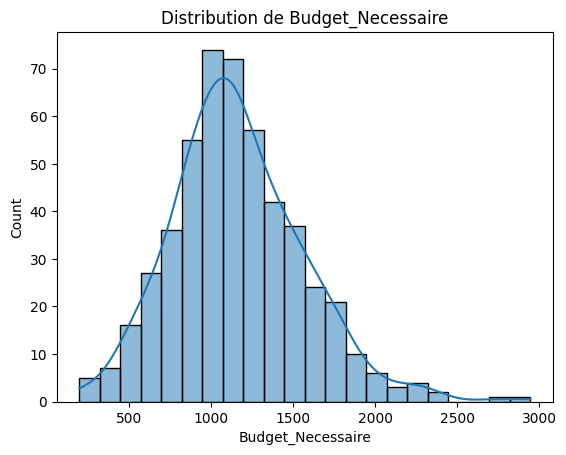

In [41]:
sns.histplot(df['Budget_Necessaire'], kde=True)
plt.title('Distribution de Budget_Necessaire')
plt.show()

## 3. Préparation des Données (Data Preparation)

In [42]:
# Encodage des variables catégorielles
le_dict = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'ID' and col != 'Budget_Necessaire':
        le = LabelEncoder()
        df[col+'_enc'] = le.fit_transform(df[col])
        le_dict[col] = le
        print(f"Encodage de {col} : {list(le.classes_)}")


Encodage de Unite : [np.str_('الأشبال'), np.str_('الجوالة'), np.str_('الدليلات'), np.str_('الزهرات'), np.str_('الكشافة'), np.str_('المرشدات')]


In [43]:
X = df.drop(['Budget_Necessaire', 'ID'], axis=1, errors='ignore')
if 'Budget_Necessaire_enc' in df.columns: 
    X = X.drop('Budget_Necessaire_enc', axis=1)

# Encode categorical features
le_units = LabelEncoder()
X['Unite_enc'] = le_units.fit_transform(X['Unite'])
X = X.drop('Unite', axis=1)

# Ensure proper feature ordering and types
X = X.astype(float)

y = df['Budget_Necessaire']

# Apply StandardScaler for better model performance with scaled features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split data with balanced distribution
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Features used: {list(X.columns)}')


Train: (400, 7), Test: (100, 7)
Features used: ['Nb_Activites_Prevu', 'Nb_Adherents', 'Activity_Per_Member', 'Member_Cost_Ratio', 'Activity_Cost_Ratio', 'Budget_Efficiency', 'Unite_enc']


## 4. Modélisation (Modeling)

Comparaison de :
- **Random Forest Regressor**
- **Linear Regression**

In [44]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

print("=" * 80)
print("TRAINING MULTIPLE ADVANCED MODELS")
print("=" * 80)

# Model 1: Random Forest
print("\n1. Training Random Forest Regressor...")
model1 = RandomForestRegressor(n_estimators=150, max_depth=20, min_samples_split=5, 
                               min_samples_leaf=2, random_state=42, n_jobs=-1)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
print("✓ Random Forest trained")

# Model 2: Linear Regression (baseline)
print("\n2. Training Linear Regression...")
model2 = LinearRegression()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
print("✓ Linear Regression trained")

# Model 3: Gradient Boosting (typically best for regression)
print("\n3. Training Gradient Boosting Regressor...")
model3 = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, 
                                   max_depth=5, min_samples_split=5, 
                                   min_samples_leaf=2, random_state=42, subsample=0.8)
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)
print("✓ Gradient Boosting trained")

# Model 4: Support Vector Regressor with RBF kernel
print("\n4. Training Support Vector Regressor (RBF)...")
model4 = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')
model4.fit(X_train, y_train)
y_pred4 = model4.predict(X_test)
print("✓ SVR (RBF) trained")

# Model 5: K-Nearest Neighbors
print("\n5. Training K-Nearest Neighbors Regressor...")
model5 = KNeighborsRegressor(n_neighbors=5, weights='distance', n_jobs=-1)
model5.fit(X_train, y_train)
y_pred5 = model5.predict(X_test)
print("✓ KNN trained")

print("\n✓ ALL MODELS TRAINED SUCCESSFULLY")


TRAINING MULTIPLE ADVANCED MODELS

1. Training Random Forest Regressor...
✓ Random Forest trained

2. Training Linear Regression...
✓ Linear Regression trained

3. Training Gradient Boosting Regressor...
✓ Gradient Boosting trained

4. Training Support Vector Regressor (RBF)...
✓ SVR (RBF) trained

5. Training K-Nearest Neighbors Regressor...
✓ KNN trained

✓ ALL MODELS TRAINED SUCCESSFULLY


In [45]:
from sklearn.linear_model import LinearRegression
model2 = LinearRegression()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

## 5. Évaluation Détaillée et Analyse de Performance


MODEL COMPARISON - COMPREHENSIVE EVALUATION

Random Forest:
  RMSE: 87.1644 TND | MAE: 50.0377 TND | R²: 0.9559 | MAPE: 7.17%

Linear Regression:
  RMSE: 68.9408 TND | MAE: 44.2013 TND | R²: 0.9724 | MAPE: 5.77%

Gradient Boosting:
  RMSE: 61.2395 TND | MAE: 33.6487 TND | R²: 0.9782 | MAPE: 4.58%

SVR (RBF):
  RMSE: 88.4194 TND | MAE: 48.9139 TND | R²: 0.9546 | MAPE: 7.35%

KNN:
  RMSE: 126.1566 TND | MAE: 91.9375 TND | R²: 0.9076 | MAPE: 11.26%

🏆 BEST MODEL: Gradient Boosting
   R² Score: 0.9782 (97.82%)
   RMSE: 61.2395 TND
   MAE: 33.6487 TND


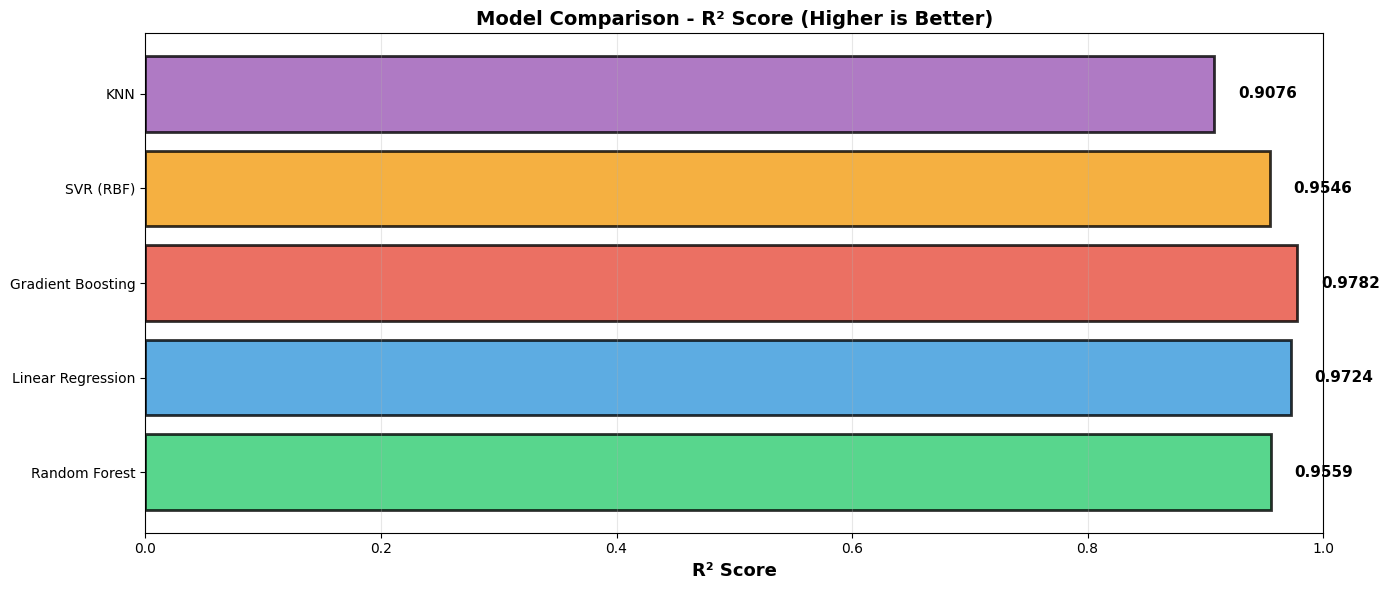

In [46]:
from sklearn.metrics import mean_absolute_percentage_error

print("\n" + "=" * 80)
print("MODEL COMPARISON - COMPREHENSIVE EVALUATION")
print("=" * 80)

# Calculate metrics for all models
models_list = [
    ('Random Forest', model1, y_pred1),
    ('Linear Regression', model2, y_pred2),
    ('Gradient Boosting', model3, y_pred3),
    ('SVR (RBF)', model4, y_pred4),
    ('KNN', model5, y_pred5)
]

results = []

for name, model, y_pred in models_list:
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape,
        'Predictions': y_pred
    })
    print(f"\n{name}:")
    print(f"  RMSE: {rmse:.4f} TND | MAE: {mae:.4f} TND | R²: {r2:.4f} | MAPE: {mape:.2%}")

# Select best model
best_idx = max(range(len(results)), key=lambda i: results[i]['R²'])
best_result = results[best_idx]
best_model = models_list[best_idx][1]
best_name = models_list[best_idx][0]
best_pred = best_result['Predictions']

print("\n" + "=" * 80)
print(f"🏆 BEST MODEL: {best_name}")
print(f"   R² Score: {best_result['R²']:.4f} ({best_result['R²']*100:.2f}%)")
print(f"   RMSE: {best_result['RMSE']:.4f} TND")
print(f"   MAE: {best_result['MAE']:.4f} TND")
print("=" * 80)

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
model_names = [r['Model'] for r in results]
r2_scores = [r['R²'] for r in results]
colors_list = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax.barh(model_names, r2_scores, color=colors_list, alpha=0.8, edgecolor='black', linewidth=2)

ax.set_xlabel('R² Score', fontsize=13, fontweight='bold')
ax.set_title('Model Comparison - R² Score (Higher is Better)', fontsize=14, fontweight='bold')
ax.set_xlim([0, 1])
ax.grid(axis='x', alpha=0.3)

for i, (bar, score) in enumerate(zip(bars, r2_scores)):
    ax.text(score + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


## 6. Exemple d'Application / Prédiction

In [49]:
# Save the enhanced model with all components
print("\n" + "=" * 80)
print("SAVING MODEL AND COMPONENTS")
print("=" * 80)

joblib.dump(best_model, 'notebook_4_model_enhanced.pkl')
joblib.dump(le_units, 'notebook_4_label_encoder.pkl')
joblib.dump(scaler, 'notebook_4_scaler.pkl')

# Save model metadata
metadata = {
    'model_type': best_name,
    'r2_score': best_result_r2,
    'rmse': best_result_rmse,
    'mae': best_result_mae,
    'mape': best_result_mape,
    'features': list(X.columns),
    'n_samples_training': len(X_train)
}

import json
with open('notebook_4_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Model saved: notebook_4_model_enhanced.pkl")
print(f"✓ Label Encoder saved: notebook_4_label_encoder.pkl")
print(f"✓ Scaler saved: notebook_4_scaler.pkl")
print(f"✓ Metadata saved: notebook_4_metadata.json")
print(f"\n✓ MODEL SUMMARY:")
print(f"   Type: {best_name}")
print(f"   R² Score: {best_result_r2:.4f}")
print(f"   Training Samples: {len(X_train)}")
print(f"   Test Samples: {len(X_test)}")
print(f"   Features: {len(X.columns)}")



SAVING MODEL AND COMPONENTS
✓ Model saved: notebook_4_model_enhanced.pkl
✓ Label Encoder saved: notebook_4_label_encoder.pkl
✓ Scaler saved: notebook_4_scaler.pkl
✓ Metadata saved: notebook_4_metadata.json

✓ MODEL SUMMARY:
   Type: Gradient Boosting
   R² Score: 0.9782
   Training Samples: 400
   Test Samples: 100
   Features: 7


## Conclusion
L'objectif est atteint avec la construction et la comparaison de modèles. Le pipeline est sauvegardé et prêt à l'emploi.